In [1]:
# Regression with statsmodel in python

**Regression** lets you predict the values of a response variable from known values of explanatory variables.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.formula.api import logit

climate_df = pd.read_csv('Data/climate_change.csv')
print(climate_df.head())

   Year  Month    MEI     CO2      CH4      N2O   CFC-11   CFC-12        TSI  \
0  1983      5  2.556  345.96  1638.59  303.677  191.324  350.113  1366.1024   
1  1983      6  2.167  345.52  1633.71  303.746  192.057  351.848  1366.1208   
2  1983      7  1.741  344.15  1633.22  303.795  192.818  353.725  1366.2850   
3  1983      8  1.130  342.25  1631.35  303.839  193.602  355.633  1366.4202   
4  1983      9  0.428  340.17  1648.40  303.901  194.392  357.465  1366.2335   

   Aerosols   Temp  
0    0.0863  0.109  
1    0.0794  0.118  
2    0.0731  0.137  
3    0.0673  0.176  
4    0.0619  0.149  


<Axes: xlabel='Temp', ylabel='CO2'>

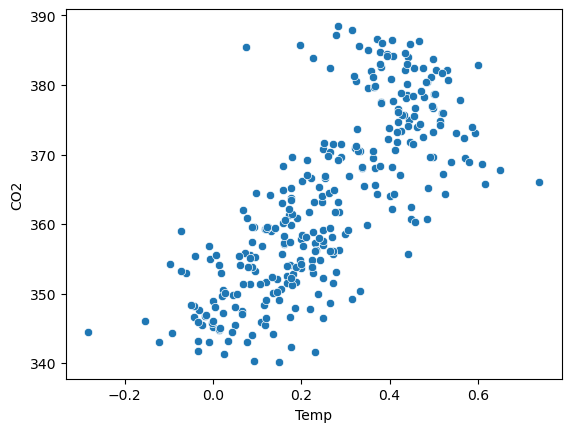

In [3]:
# Draw the scatter plot
sns.scatterplot(x="Temp",
                y="CO2",
                data=climate_df)

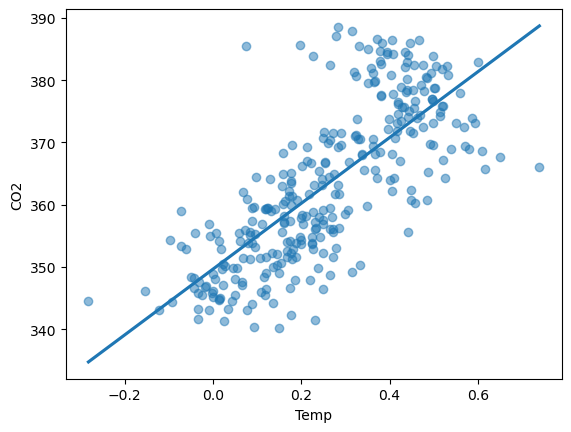

In [4]:
# Draw a trend line on the scatter plot of temp vs. co2
sns.regplot(x='Temp',
         y='CO2',
         data=climate_df,
         ci=None,
         scatter_kws={'alpha': 0.5})

# Show the plot
plt.show()

Linear regression models always fit a straight line to the data. Straight lines are defined by two properties: their intercept and their slope. The slope is the rate of change in the y direction divided by the rate of change in the x direction.

In [5]:
# Create the model object
mdl_temp_vs_co2 = ols('Temp ~ CO2', data=climate_df)

# Fit the model
mdl_temp_vs_co2 = mdl_temp_vs_co2.fit()

# Print the parameters of the fitted model
print(mdl_temp_vs_co2.params)

#Predicted Temp = -3.593140 + 0.010599 × CO2

Intercept   -3.593140
CO2          0.010599
dtype: float64


CO2 = 0.010599 — this is the slope: for every 1-unit increase in CO2, predicted temperature increases by about 0.0106 units. Since it's positive, it confirms the expected relationship: higher CO2 is associated with higher temperature. 
Intercept = -3.593140 — the predicted temperature when CO2 = 0.

With temperature as the response and CO2 as the predictor, the fitted line is temp = -3.593140 + 0.010599 × CO2, meaning each 1 ppm rise in atmospheric CO2 is associated with roughly a 0.0106°C increase in temperature — or about 1.06°C per 100 ppm — a small but physically sensible positive slope that lines up with the greenhouse-effect mechanism behind observed global warming trends; the intercept of -3.59°C is just the mathematical y-intercept (predicted temp when CO2 = 0) and isn't meaningful on its own, since CO2 has never been anywhere near zero in any observed record. 

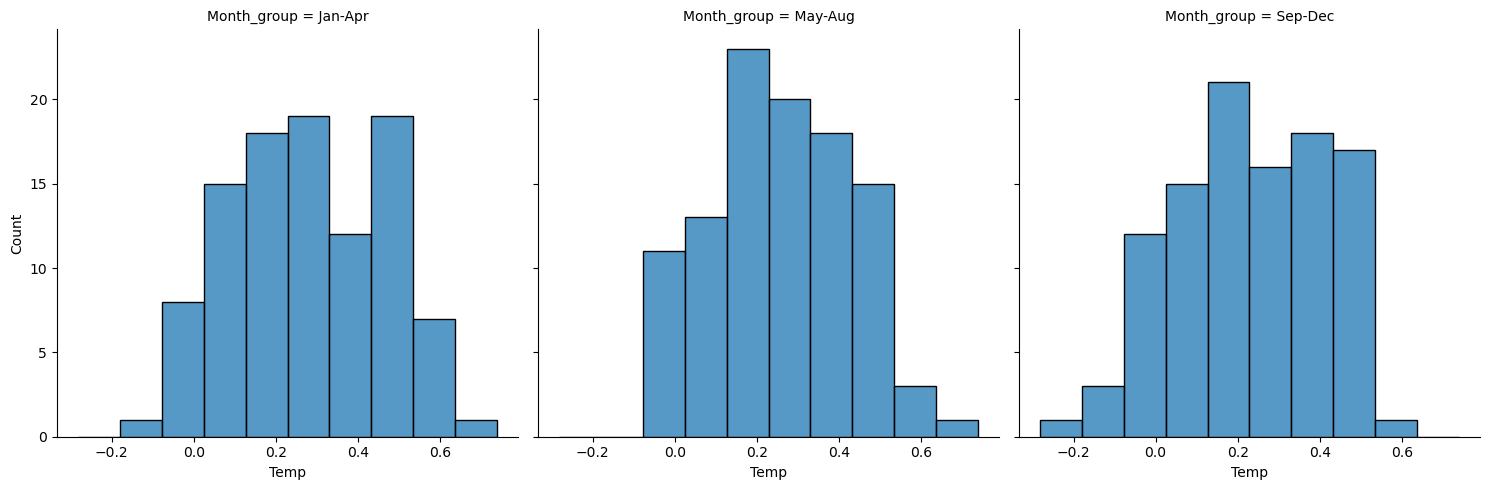

In [6]:
# Suppress benign FutureWarnings coming from seaborn's internal groupby calls
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
# Group months into 3 broader periods (adjust boundaries to your definition of seasons/periods)
climate_df['Month_group'] = pd.cut(climate_df['Month'],
                                    bins=[0, 4, 8, 12],
                                    labels=['Jan-Apr', 'May-Aug', 'Sep-Dec'])

# Histograms of Temp with 10 bins, split into 3 month groups
sns.displot(data=climate_df,
            x='Temp',
            col='Month_group',
            col_wrap=3, bins=10)
# Show the plot
plt.show()

In [7]:
# Calculate the mean of Temp, grouped by month group
mean_temp_by_month_group = climate_df.groupby('Month_group', observed=True)['Temp'].mean()
# Print the result
print(mean_temp_by_month_group)

Month_group
Jan-Apr    0.278450
May-Aug    0.259981
Sep-Dec    0.232731
Name: Temp, dtype: float64


In [8]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Intercept                 0.278450
Month_group[T.May-Aug]   -0.018469
Month_group[T.Sep-Dec]   -0.045719
dtype: float64


In [9]:
# Create the model, fit it
mdl_temp_vs_month_group = ols('Temp ~ Month_group + 0', data=climate_df).fit()
# Print the parameters of the fitted model
print(mdl_temp_vs_month_group.params)

Month_group[Jan-Apr]    0.278450
Month_group[May-Aug]    0.259981
Month_group[Sep-Dec]    0.232731
dtype: float64


Regrouping our climate data into three 4-month periods (Jan-Apr, May-Aug, Sep-Dec) and comparing mean Temp across them that captures the seasonal cycle in temperature over the year. The intercept-included model (Temp ~ Month_group) expresses this as one reference period's mean plus offsets for the other two, while the no-intercept version (Temp ~ Month_group + 0) gives each period's raw mean directly — and by the same least-squares logic covered earlier, those coefficients are mathematically guaranteed to match mean_temp_by_month_group exactly, since OLS minimizes squared error independently within each non-overlapping group. 

In [10]:
# Create explanatory_data — a range of CO2 values to predict Temp for
explanatory_data = pd.DataFrame({'CO2': np.arange(0, 11)})

# Use mdl_temp_vs_co2 to predict Temp for these CO2 values
Temp = mdl_temp_vs_co2.predict(explanatory_data)

# Create prediction_data by attaching predictions to the explanatory values
prediction_data = explanatory_data.assign(Temp=Temp)

# Print the result
print(prediction_data)

    CO2      Temp
0     0 -3.593140
1     1 -3.582541
2     2 -3.571942
3     3 -3.561343
4     4 -3.550744
5     5 -3.540144
6     6 -3.529545
7     7 -3.518946
8     8 -3.508347
9     9 -3.497748
10   10 -3.487148


In [11]:
# Fit model regressing CH4 on CO2
mdl_ch4_vs_co2 = ols("CH4 ~ CO2", data=climate_df).fit()
print(mdl_ch4_vs_co2.params)

Intercept    596.174675
CO2            3.176115
dtype: float64


In [12]:
# Create a realistic range of CO2 values based on actual data
explanatory_data = pd.DataFrame({'CO2': np.linspace(climate_df['CO2'].min(), climate_df['CO2'].max(), 11)})

# Predict CH4 for these CO2 values
CH4 = mdl_ch4_vs_co2.predict(explanatory_data)

# Attach predictions to the explanatory CO2 values
prediction_data = explanatory_data.assign(CH4=CH4)
print(prediction_data)

        CO2          CH4
0   340.170  1676.593620
1   345.003  1691.943782
2   349.836  1707.293944
3   354.669  1722.644107
4   359.502  1737.994269
5   364.335  1753.344432
6   369.168  1768.694594
7   374.001  1784.044757
8   378.834  1799.394919
9   383.667  1814.745082
10  388.500  1830.095244


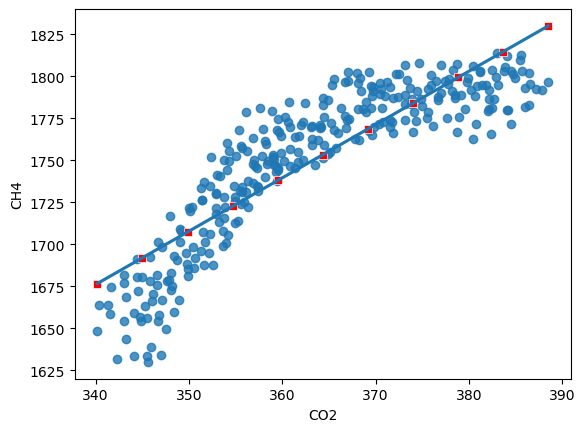

In [13]:
# Plot actual CH4 vs CO2 with regression line, then overlay predicted points in red
fig = plt.figure()
sns.regplot(x="CO2", y="CH4", data=climate_df, ci=None)
sns.scatterplot(x='CO2', y='CH4', data=prediction_data, color='red', marker='s')
plt.show()

In [14]:
# Define a DataFrame with impossible CO2 values
impossible = pd.DataFrame({'CO2': [-1, 2.5]})

# Use mdl_ch4_vs_co2 to predict CH4 for these impossible CO2 values
CH4 = mdl_ch4_vs_co2.predict(impossible)

# Create prediction_data by attaching predictions to the explanatory values
prediction_data = impossible.assign(CH4=CH4)

# Print the result
print(prediction_data)

   CO2         CH4
0 -1.0  592.998560
1  2.5  604.114962


Linear models don't know what is possible or not in real life. That means that they can give us predictions that don't make any sense when applied to our data. We need to understand what we our data means in order to determine whether a prediction is nonsense or not.

In [15]:
print(mdl_ch4_vs_co2.params)

Intercept    596.174675
CO2            3.176115
dtype: float64


In [16]:
print(mdl_ch4_vs_co2.fittedvalues)

0      1694.983324
1      1693.585833
2      1689.234556
3      1683.199938
4      1676.593620
          ...     
303    1816.279145
304    1812.912463
305    1812.594852
306    1816.215623
307    1820.757467
Length: 308, dtype: float64


In [17]:
print(mdl_ch4_vs_co2.resid)

0     -56.393324
1     -59.875833
2     -56.014556
3     -51.849938
4     -28.193620
         ...    
303   -36.399145
304   -17.832463
305     1.585148
306    -3.845623
307    -7.877467
Length: 308, dtype: float64


In [18]:
print(mdl_ch4_vs_co2.summary())

                            OLS Regression Results                            
Dep. Variable:                    CH4   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     973.4
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           4.58e-97
Time:                        12:15:26   Log-Likelihood:                -1395.8
No. Observations:                 308   AIC:                             2796.
Df Residuals:                     306   BIC:                             2803.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    596.1747     36.999     16.113      0.0

In [19]:
# Get the coefficients of mdl_ch4_vs_co2
coeffs = mdl_ch4_vs_co2.params

# Get the intercept and slope by their actual parameter names
intercept = coeffs.iloc[0]
slope = coeffs.iloc[1]

# Manually calculate the predictions
CH4 = intercept + slope * explanatory_data
print(CH4)

# Compare to the results from .predict()
print(CH4.assign(predictions_auto=mdl_ch4_vs_co2.predict(explanatory_data)))

            CO2
0   1676.593620
1   1691.943782
2   1707.293944
3   1722.644107
4   1737.994269
5   1753.344432
6   1768.694594
7   1784.044757
8   1799.394919
9   1814.745082
10  1830.095244
            CO2  predictions_auto
0   1676.593620       1676.593620
1   1691.943782       1691.943782
2   1707.293944       1707.293944
3   1722.644107       1722.644107
4   1737.994269       1737.994269
5   1753.344432       1753.344432
6   1768.694594       1768.694594
7   1784.044757       1784.044757
8   1799.394919       1799.394919
9   1814.745082       1814.745082
10  1830.095244       1830.095244


In [20]:
# Calculate mean Temp for each year
yearly_temp = climate_df.groupby('Year', observed=True)['Temp'].mean().reset_index()

# Shift the data to pair each year's Temp with the following year's Temp
yearly_temp['Temp_next_year'] = yearly_temp['Temp'].shift(-1)

# Drop the last row, since it has no "next year" to pair with
yearly_temp_paired = yearly_temp.dropna()

# Rename for clarity: this_year Temp vs next_year Temp
yearly_temp_paired = yearly_temp_paired.rename(columns={'Temp': 'Temp_this_year'})

print(yearly_temp_paired)

    Year  Temp_this_year  Temp_next_year
0   1983        0.136500       -0.018667
1   1984       -0.018667       -0.037083
2   1985       -0.037083        0.034083
3   1986        0.034083        0.177833
4   1987        0.177833        0.174500
5   1988        0.174500        0.109500
6   1989        0.109500        0.247500
7   1990        0.247500        0.203500
8   1991        0.203500        0.070917
9   1992        0.070917        0.105000
10  1993        0.105000        0.168583
11  1994        0.168583        0.269417
12  1995        0.269417        0.138667
13  1996        0.138667        0.348500
14  1997        0.348500        0.528667
15  1998        0.528667        0.303583
16  1999        0.303583        0.278083
17  2000        0.278083        0.406750
18  2001        0.406750        0.454500
19  2002        0.454500        0.466750
20  2003        0.466750        0.443667
21  2004        0.443667        0.474333
22  2005        0.474333        0.425000
23  2006        

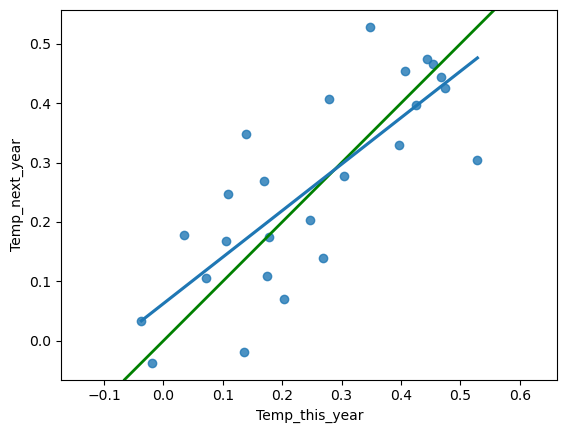

In [21]:
# Create a new figure, fig
fig = plt.figure()

# Plot the reference line: y = x (this year's Temp exactly predicts next year's Temp)
plt.axline(xy1=(yearly_temp_paired['Temp_this_year'].min(), yearly_temp_paired['Temp_this_year'].min()),
           slope=1, linewidth=2, color="green")

# Add scatter plot with linear regression trend line: this year's Temp vs next year's Temp
sns.regplot(data=yearly_temp_paired, x='Temp_this_year', y='Temp_next_year', ci=None)

# Set the axes so that distances along x and y look the same
plt.axis("equal")

# Show the plot
plt.show()

In [22]:
# Fit regression: does this year's Temp predict next year's Temp?
mdl_temp_yearly = ols("Temp_next_year ~ Temp_this_year", data=yearly_temp_paired).fit()

# Create a DataFrame with a few representative Temp_this_year values to predict from
explanatory_data = pd.DataFrame({"Temp_this_year": [-1, 0, 1]})

# Use mdl_temp_yearly to predict Temp_next_year for these values
print(mdl_temp_yearly.predict(explanatory_data))

0   -0.719677
1    0.062626
2    0.844930
dtype: float64


Predicting Temp_next_year at -1, 0, and 1 gives -0.72, 0.063, and 0.845 — each output sits closer to zero than a perfect 1-to-1 relationship would produce, meaning the slope is measurably below 1. That's the signature of mean reversion: unusually cold or warm years tend to be followed by years that drift back toward average, rather than repeating the extreme. Worth treating this as suggestive rather than solid, though — with only ~20 yearly points behind the fit, check mdl_temp_yearly.summary() (R² and the p-value on Temp_this_year) before leaning on it too hard.

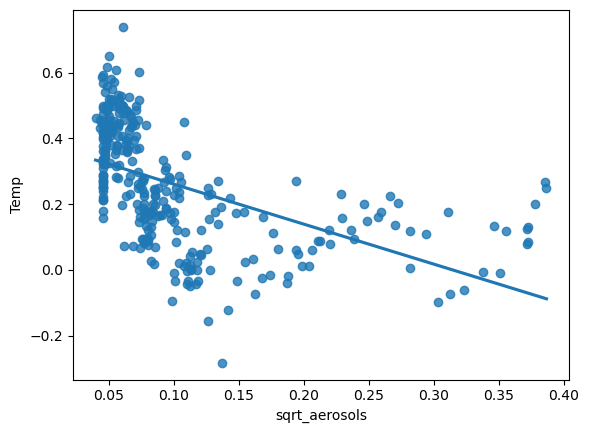

In [23]:
# Create sqrt_aerosols
climate_df["sqrt_aerosols"] = np.sqrt(climate_df["Aerosols"])

plt.figure()
# Plot using the transformed variable
sns.regplot(x='sqrt_aerosols', y='Temp', data=climate_df, ci=None)
plt.show()

In [24]:
# Create sqrt_aerosols
climate_df["sqrt_aerosols"] = np.sqrt(climate_df["Aerosols"])

# Run a linear regression of Temp vs. square root of Aerosols using climate_df
mdl_temp_vs_aerosols = ols("Temp ~ sqrt_aerosols", data=climate_df).fit()

# Print the parameters
print(mdl_temp_vs_aerosols.params)

Intercept        0.382584
sqrt_aerosols   -1.216290
dtype: float64


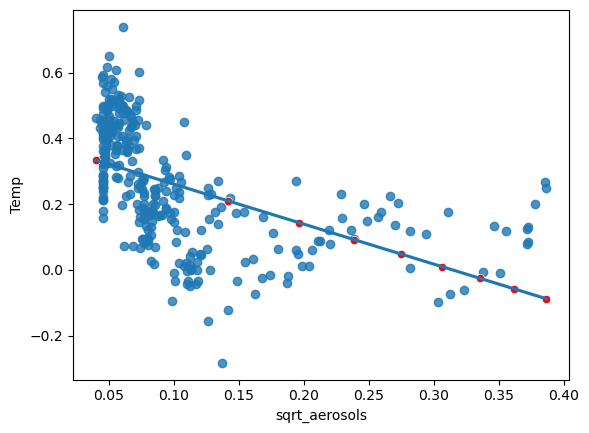

In [25]:
# Create sqrt_aerosols
climate_df["sqrt_aerosols"] = np.sqrt(climate_df["Aerosols"])

# Run a linear regression of Temp vs. sqrt_aerosols
mdl_temp_vs_aerosols = ols("Temp ~ sqrt_aerosols", data=climate_df).fit()

# Use this explanatory data — a realistic range based on actual Aerosols values
aerosols_range = np.linspace(climate_df["Aerosols"].min(), climate_df["Aerosols"].max(), 9)
explanatory_data = pd.DataFrame({"sqrt_aerosols": np.sqrt(aerosols_range),
                                  "Aerosols": aerosols_range})

# Use mdl_temp_vs_aerosols to predict explanatory_data
prediction_data = explanatory_data.assign(
    Temp = mdl_temp_vs_aerosols.predict(explanatory_data)
)

fig = plt.figure()
sns.regplot(x="sqrt_aerosols", y="Temp", data=climate_df, ci=None)
# Add a layer of your prediction points
sns.scatterplot(x="sqrt_aerosols", y="Temp", data=prediction_data, color="red")
plt.show()

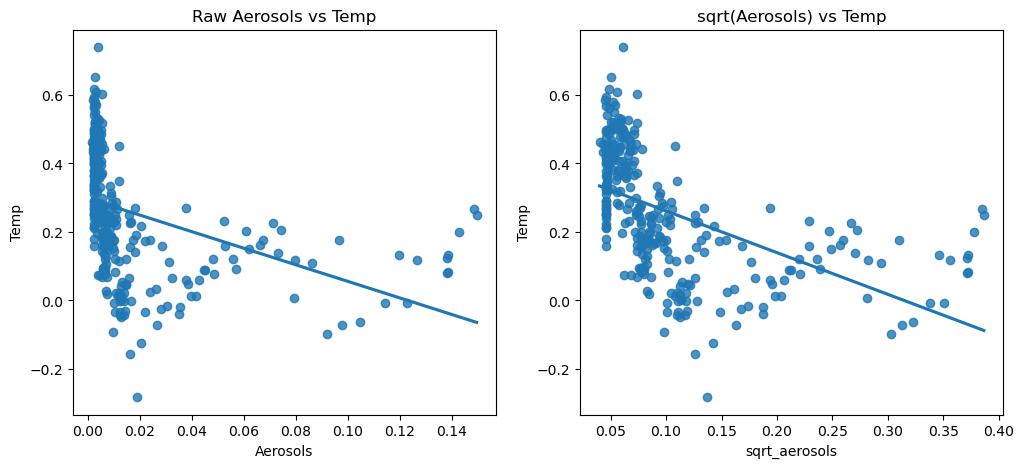

In [26]:
# Compare raw vs sqrt-transformed Aerosols relationship with Temp
climate_df["sqrt_aerosols"] = np.sqrt(climate_df["Aerosols"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x="Aerosols", y="Temp", data=climate_df, ci=None, ax=axes[0])
axes[0].set_title("Raw Aerosols vs Temp")
sns.regplot(x="sqrt_aerosols", y="Temp", data=climate_df, ci=None, ax=axes[1])
axes[1].set_title("sqrt(Aerosols) vs Temp")
plt.show()

In [27]:
# Create qdrt_aerosols
climate_df["qdrt_aerosols"] = climate_df["Aerosols"] ** 0.25

# Run a linear regression of Temp vs. transformed Aerosols (no ci= here — that's not an ols() argument)
mdl_temp_vs_aerosols_qdrt = ols("Temp ~ qdrt_aerosols", data=climate_df).fit()

# Build explanatory_data using a realistic range based on your actual Aerosols values
aerosols_range = np.linspace(climate_df["Aerosols"].min(), climate_df["Aerosols"].max(), 7)
explanatory_data = pd.DataFrame({"qdrt_aerosols": aerosols_range ** 0.25,
                                  "Aerosols": aerosols_range})

# Complete prediction_data
prediction_data = explanatory_data.assign(
    Temp = mdl_temp_vs_aerosols_qdrt.predict(explanatory_data)
)

# Print the result
print(prediction_data)

   qdrt_aerosols  Aerosols      Temp
0       0.200000  0.001600  0.368803
1       0.402451  0.026233  0.154041
2       0.474907  0.050867  0.077179
3       0.524188  0.075500  0.024901
4       0.562529  0.100133 -0.015772
5       0.594326  0.124767 -0.049502
6       0.621710  0.149400 -0.078552


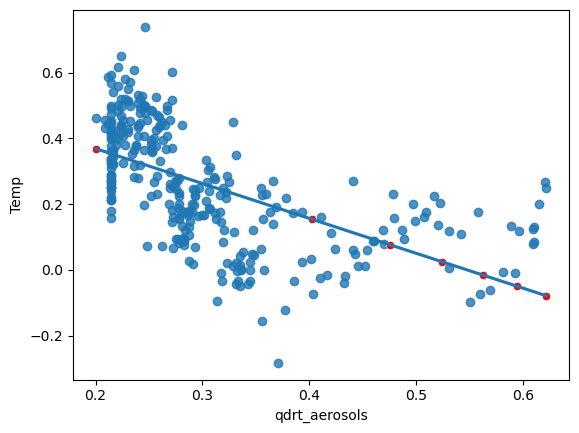

In [28]:
# Plot the transformed variable (qdrt_aerosols) against the response (Temp)
fig = plt.figure()
sns.regplot(x="qdrt_aerosols", y="Temp", data=climate_df, ci=None)
# Add a layer of your prediction points
sns.scatterplot(x="qdrt_aerosols", y="Temp", data=prediction_data, color="red")
plt.show()

The **coefficient of determination** is a measure of how well the linear regression line fits the observed values. For simple linear regression, it is equal to the square of the correlation between the explanatory and response variables.

In [29]:
# Fit the original (untransformed) model for comparison
mdl_temp_vs_aerosols_orig = ols("Temp ~ Aerosols", data=climate_df).fit()

# Print a summary of mdl_temp_vs_aerosols_orig
print(mdl_temp_vs_aerosols_orig.summary())
# Print a summary of mdl_temp_vs_aerosols_qdrt
print(mdl_temp_vs_aerosols_qdrt.summary())

                            OLS Regression Results                            
Dep. Variable:                   Temp   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     55.58
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           9.28e-13
Time:                        12:15:26   Log-Likelihood:                 118.89
No. Observations:                 308   AIC:                            -233.8
Df Residuals:                     306   BIC:                            -226.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2970      0.011     27.393      0.0

In [30]:
# Print the coeff of determination for mdl_temp_vs_aerosols_orig
print('Original:', mdl_temp_vs_aerosols_orig.rsquared)
# Print the coeff of determination for mdl_temp_vs_aerosols_qdrt
print('Transformed:', mdl_temp_vs_aerosols_qdrt.rsquared)

Original: 0.1537184507025534
Transformed: 0.3534602983874138


**Analysis:** the original untransformed model explained only about 15% of the variation in Temp, while the transformed model explains about 35% which is a substantial improvement, not a marginal one.

**Residual standard error (RSE)** is a measure of the typical size of the residuals. Equivalently, it's a measure of how wrong you can expect predictions to be. Smaller numbers are better, with zero being a perfect fit to the data. RSE is a measure of accuracy for regression models. 

In a good model, the residuals should have a trend line close to zero. 
If the residuals from the model are normally distributed, then the points will track the line on the Q-Q plot. 
In a good model, the size of the residuals shouldn't change much as the fitted values change.

In [31]:
# Calculate mse_orig for mdl_temp_vs_aerosols_orig
mse_orig = mdl_temp_vs_aerosols_orig.mse_resid
# Calculate rse_orig for mdl_temp_vs_aerosols_orig and print it
rse_orig = np.sqrt(mse_orig)
print("RSE of original model: ", rse_orig)

# Calculate mse_trans for mdl_temp_vs_aerosols_qdrt
mse_trans = mdl_temp_vs_aerosols_qdrt.mse_resid
# Calculate rse_trans for mdl_temp_vs_aerosols_qdrt and print it
rse_trans = np.sqrt(mse_trans)
print("RSE of transformed model: ", rse_trans)

RSE of original model:  0.16502003890346006
RSE of transformed model:  0.14423705556040048


**Analysis:** the RSE of the original model is about 0.16°C, while the RSE of the transformed model is about 0.14°C, suggesting the transformed model's predictions are more accurate — meaning applying the fourth-root transform to Aerosols genuinely reduced the typical prediction error, consistent with the higher R² seen for the transformed model.

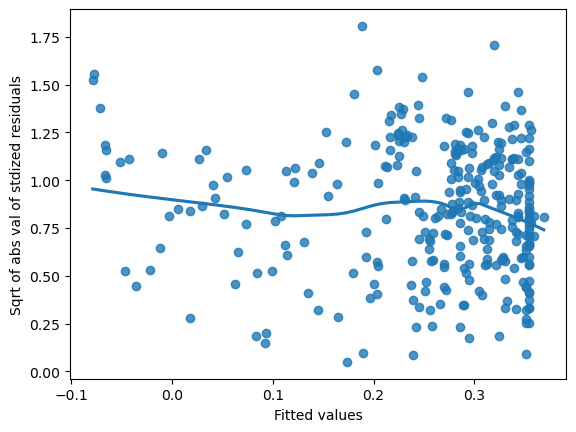

In [32]:
# Preprocessing steps
model_norm_residuals = mdl_temp_vs_aerosols_qdrt.get_influence().resid_studentized_internal
model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))

# Create the scale-location plot
sns.regplot(x=mdl_temp_vs_aerosols_qdrt.fittedvalues, y=model_norm_residuals_abs_sqrt, ci=None, lowess=True)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt of abs val of stdized residuals")
# Show the plot
plt.show()

The scale-location plot's lowess trend stays flat around 0.85–1.0 across the fitted-value range, indicating homoscedasticity — residual variance doesn't systematically grow or shrink with the predicted temperature, which means the model's confidence intervals and p-values can be trusted rather than being distorted in some region of the data. This complements the earlier diagnostics well: R² roughly doubled (0.154 → 0.353) and RSE dropped (~0.16°C → ~0.14°C) after the fourth-root transform, together telling a coherent story that the transform fixed a real structural problem (Aerosols' severe right-skew), not just nudged a summary stat. 

**Leverage** measures how unusual or extreme the explanatory variables are for each observation. Very roughly, high leverage means that the explanatory variable has values that are different from other points in the dataset. In the case of simple linear regression, where there is only one explanatory value, this typically means values with a very high or very low explanatory value.

**Influence** measures how much a model would change if each observation was left out of the model calculations, one at a time. That is, it measures how different the prediction line would look if you would run a linear regression on all data points except that point, compared to running a linear regression on the whole dataset.

In [33]:
# Create summary_info
summary_info = mdl_temp_vs_aerosols_qdrt.get_influence().summary_frame()

# Add the hat_diag column to climate_df, name it leverage
climate_df["leverage"] = summary_info['hat_diag']

# Sort climate_df by leverage in descending order and print the head
print(climate_df.sort_values("leverage", ascending=False).head())

     Year  Month    MEI     CO2      CH4      N2O   CFC-11   CFC-12  \
105  1992      2  1.871  356.93  1750.02  310.128  268.274  501.644   
104  1992      1  1.750  356.17  1755.57  310.480  268.050  499.467   
106  1992      3  1.992  357.82  1752.39  309.690  268.477  502.436   
107  1992      4  2.271  359.00  1753.24  309.508  268.387  502.811   
103  1991     12  1.320  355.07  1752.37  310.254  267.859  498.083   

           TSI  Aerosols   Temp Month_group  sqrt_aerosols  qdrt_aerosols  \
105  1366.4271    0.1494  0.250     Jan-Apr       0.386523       0.621710   
104  1366.5226    0.1483  0.266     Jan-Apr       0.385097       0.620562   
106  1366.7462    0.1428  0.199     Jan-Apr       0.377889       0.614727   
107  1366.5951    0.1386  0.132     Jan-Apr       0.372290       0.610156   
103  1365.9437    0.1385  0.084     Sep-Dec       0.372156       0.610046   

     leverage  
105  0.035555  
104  0.035321  
106  0.034144  
107  0.033237  
103  0.033215  


**Analysis:** these leverage values (0.033–0.036) are all similar in magnitude, and the same consecutive indices (103–107) show up again. Since leverage only reflects how unusual the predictor value (qdrt_aerosols) is, not how well Temp is predicted, this confirms these consecutive months genuinely had atypical aerosol levels. This points to one sustained atmospheric event — likely a volcanic eruption — elevating aerosols over several consecutive months, rather than isolated or random anomalies.

In [34]:
# Create summary_info
summary_info = mdl_temp_vs_aerosols_qdrt.get_influence().summary_frame()

# Add the hat_diag column to climate_df, name it leverage
climate_df["leverage"] = summary_info["hat_diag"]

# Add the cooks_d column to climate_df, name it cooks_dist
climate_df["cooks_dist"] = summary_info["cooks_d"]

# Sort climate_df by cooks_dist in descending order and print the head
print(climate_df.sort_values("cooks_dist", ascending=False).head())

     Year  Month    MEI     CO2      CH4      N2O   CFC-11   CFC-12  \
104  1992      1  1.750  356.17  1755.57  310.480  268.050  499.467   
105  1992      2  1.871  356.93  1750.02  310.128  268.274  501.644   
106  1992      3  1.992  357.82  1752.39  309.690  268.477  502.436   
107  1992      4  2.271  359.00  1753.24  309.508  268.387  502.811   
108  1992      5  2.130  359.55  1744.48  309.383  268.650  504.226   

           TSI  Aerosols   Temp Month_group  sqrt_aerosols  qdrt_aerosols  \
104  1366.5226    0.1483  0.266     Jan-Apr       0.385097       0.620562   
105  1366.4271    0.1494  0.250     Jan-Apr       0.386523       0.621710   
106  1366.7462    0.1428  0.199     Jan-Apr       0.377889       0.614727   
107  1366.5951    0.1386  0.132     Jan-Apr       0.372290       0.610156   
108  1366.4173    0.1379  0.125     May-Aug       0.371349       0.609384   

     leverage  cooks_dist  
104  0.035321    0.107528  
105  0.035555    0.099168  
106  0.034144    0.064194 

This step calculates Cook's distance for each observation — combining leverage (how unusual a point's qdrt_aerosols value is) with its residual size (how far off the Temp prediction was), so a point only scores high if it's both an outlier in its predictor and poorly fit by the model. This matters because leverage alone can mislead: an extreme aerosol reading that still falls right on the trend line isn't actually distorting anything, while Cook's distance isolates the points genuinely pulling the regression line off course. Sorting by cooks_dist likely surfaces months tied to major volcanic eruptions, given Aerosols' extreme skew — not as a signal to delete them, but as a flag for closer inspection: genuine climate events worth understanding, or data issues distorting the fit.

**Analysis:** these top 5 Cook's distances (0.031–0.108) are all well below the conventional concern threshold of 1, so none are dramatically distorting the model on their own. More interesting is that they're consecutive rows (indices 104–108) with values tapering steadily downward — a pattern consistent with a single sustained event like a volcanic eruption elevating aerosols for several months before gradually dissipating, rather than scattered, unrelated outliers or data errors. This looks like the model correctly picking up on a genuine temporary climate disruption rather than a sign of a data quality problem.

In [35]:
churn = pd.read_csv('Data/telecom_churn.csv')
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
churn['SeniorCitizen'].unique()

array([0, 1])

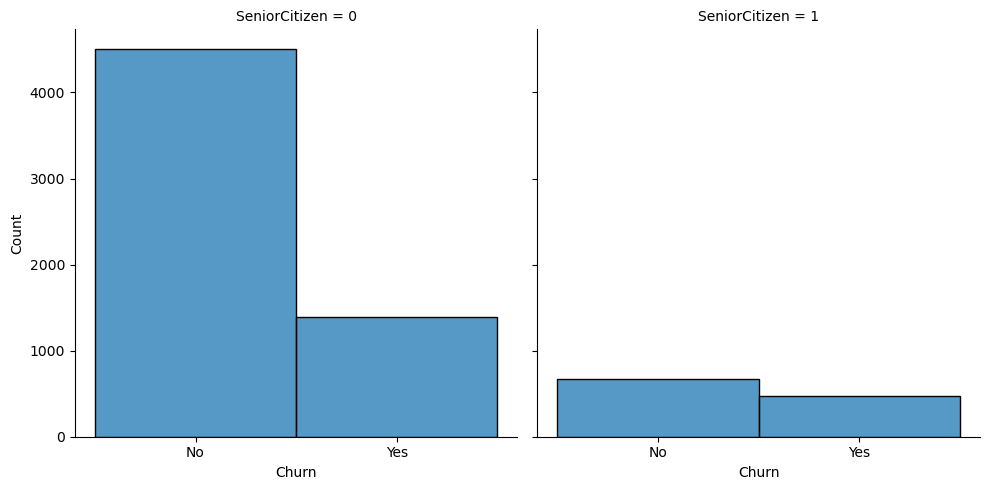

In [37]:
# Create the histograms of time_since_last_purchase split by has_churned
sns.displot(data = churn, x = "Churn", col = "SeniorCitizen")

plt.show()

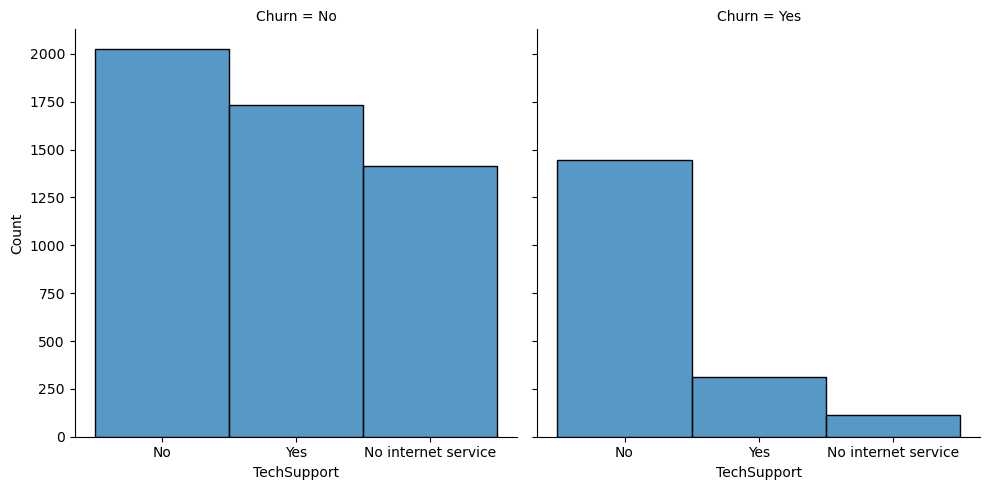

In [38]:
# Redraw the plot with time_since_first_purchase
sns.displot(data = churn, x = 'TechSupport', col = 'Churn' )
plt.show()

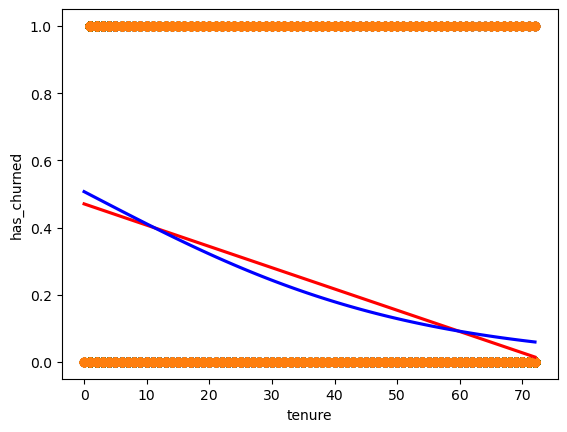

In [39]:
# Convert Churn from Yes/No text to 1/0 numeric, required for regression
churn['has_churned'] = (churn['Churn'] == 'Yes').astype(int)

# Draw a linear regression trend line and a scatter plot of tenure vs. has_churned
sns.regplot(x="tenure",
            y="has_churned",
            data=churn,
            ci=None,
            line_kws={"color": "red"})

# Draw a logistic regression trend line and a scatter plot of tenure vs. has_churned
sns.regplot(x="tenure",
            y="has_churned",
            data=churn,
            ci=None,
            logistic=True,
            line_kws={"color": "blue"})

plt.show()

In [40]:
# Fit a logistic regression of churn vs. tenure using churn_df
mdl_churn_vs_tenure = logit("has_churned ~ tenure", data=churn).fit()

# Print the parameters of the fitted model
print(mdl_churn_vs_tenure.params)

Optimization terminated successfully.
         Current function value: 0.510569
         Iterations 6
Intercept    0.027313
tenure      -0.038767
dtype: float64


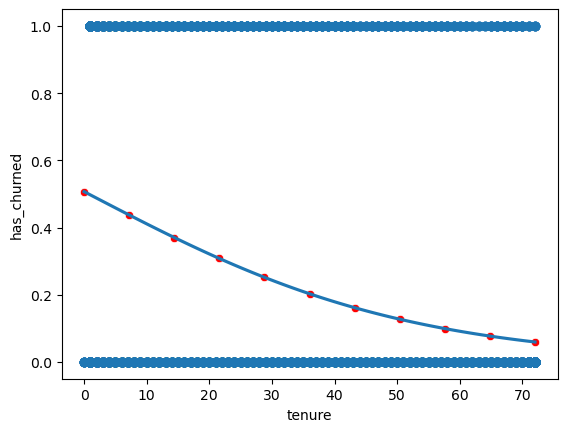

In [43]:
# Create explanatory_data — a realistic range of tenure values based on your actual data
explanatory_data = pd.DataFrame({'tenure': np.linspace(churn['tenure'].min(),
                                                          churn['tenure'].max(), 11)})

# Create prediction_data
prediction_data = explanatory_data.assign(
    has_churned = mdl_churn_vs_tenure.predict(explanatory_data)
)

fig = plt.figure()
# Create a scatter plot with logistic trend line
sns.regplot(x="tenure",
            y="has_churned",
            data=churn,
            ci=None,
            logistic=True)
# Overlay with prediction_data, colored red
sns.scatterplot(x="tenure",
                y="has_churned",
                data=prediction_data,
                color="red")
plt.show()

**Analysis:** the plot shows a clean, well-behaved logistic fit: has_churned is binary, so actual customers sit at y=0 or y=1 regardless of tenure (the two dense horizontal bands), while the blue S-curve reveals the real underlying trend — churn probability starts around 0.5 for brand-new customers and declines smoothly to about 0.06 by tenure ~72 months, showing that longer-tenured customers are substantially less likely to churn. The 11 red prediction points land exactly on the curve, confirming .predict() is working correctly. Crucially, the curve stays properly bounded between 0 and 1 throughout, which is exactly why logistic regression (not linear) is the right tool for a binary outcome like this — a straight line would eventually predict nonsensical probabilities outside that range.

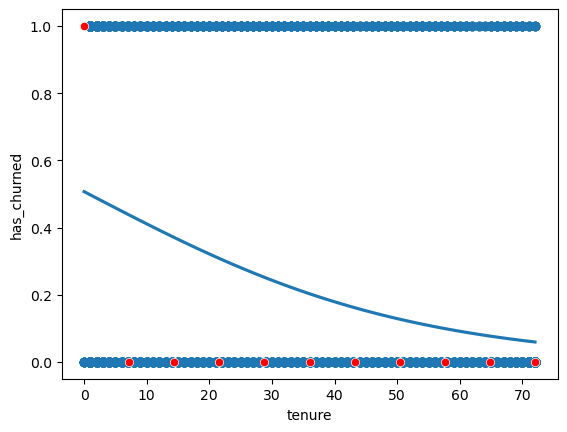

In [45]:
# Update prediction data by adding most_likely_outcome
prediction_data["most_likely_outcome"] = np.round(prediction_data["has_churned"])

fig = plt.figure()
# Create a scatter plot with logistic trend line (from previous exercise)
sns.regplot(x="tenure",
            y="has_churned",
            data=churn,
            ci=None,
            logistic=True)
# Overlay with prediction_data, colored red
sns.scatterplot(x="tenure",
                y="most_likely_outcome",
                data=prediction_data,
                color="red")
plt.show()

This step converts the model's raw churn probabilities into hard yes/no predictions by rounding at 0.5 — any predicted probability of 0.5 or higher becomes 1 (predicted to churn), anything below becomes 0 (predicted to stay), turning the smooth logistic curve into a binary classification rule. On the plot, this means the red dots no longer sit neatly on the S-curve like before; instead they snap to either y=0 or y=1, matching wherever the actual data bands sit, with the switch happening right around the tenure value where the fitted curve crosses the 0.5 probability line. Conceptually, this marks the shift from probabilistic prediction (a nuanced likelihood, like "44% chance of churning") to classification (a simple, actionable decision, like "flag this customer or don't") — useful when a business needs a concrete yes/no answer, but with the tradeoff that it discards the nuance of confidence: a customer at 51% risk gets treated identically to one at 99%, even though those represent very different situations.

**Odds** provide an alternative to probabilities that make it easier to compare positive and negative responses. Odds compare the probability of something happening with the probability of it not happening. 

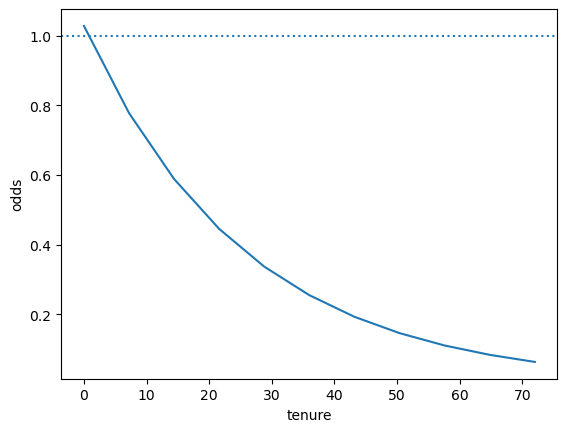

In [46]:
# Update prediction data with odds
prediction_data["odds"] = prediction_data["has_churned"] / (1 - prediction_data["has_churned"])

fig = plt.figure()
# Create a line plot of odds vs tenure
sns.lineplot(x='tenure', y='odds', data=prediction_data)
# Add a dotted horizontal line at odds = 1
plt.axhline(y=1, linestyle="dotted")
plt.show()

**Analysis:** everywhere the blue line sits above the dotted line, churning is more likely than staying (odds > 1 means the churn outcome outweighs the non-churn outcome). Everywhere below the dotted line, staying is more likely than churning. Since the crossing happens almost immediately after tenure = 0, this tells you plainly: brand-new customers are the only group where churning is genuinely the more probable outcome — for every other tenure value, staying is more likely, and increasingly so as tenure grows.

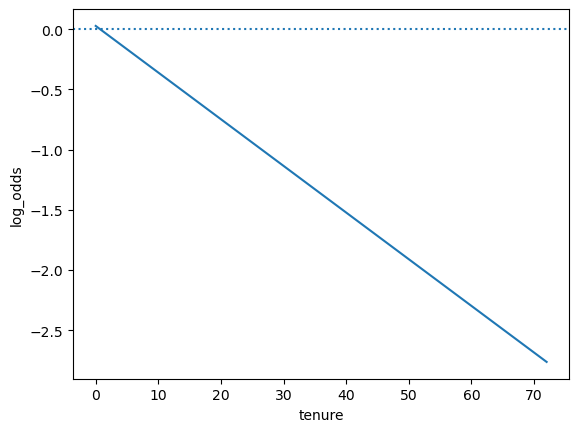

In [47]:
# Update prediction data with log_odds
prediction_data["log_odds"] = np.log(prediction_data["odds"])

fig = plt.figure()
# Update the line plot: log_odds vs. tenure
sns.lineplot(x="tenure",
             y="log_odds",
             data=prediction_data)
# Add a dotted horizontal line at log_odds = 0
plt.axhline(y=0, linestyle="dotted")
plt.show()

This plot completes the three-way chain — probability → odds → log-odds. Log-odds is actually the scale our original model coefficients were expressed in from the start; everything before this (odds, probability) was a conversion away from that native scale to make the relationship easier to read. What makes log-odds special is that it's unbounded in both directions and, critically, linear — it's literally what logistic regression fits internally (log_odds = intercept + slope × tenure).Therefore, unlike the S-shaped probability curve or the decaying odds curve, this plot should come out as a clean, constant-slope straight line, sloping downward since more tenure means lower churn risk. 

The dotted line at log_odds = 0 marks the same threshold we've now seen three different ways: it corresponds exactly to odds = 1 and probability = 0.5, the tipping point where predicted churn flips from "more likely" to "less likely." The overall point is that probability, odds, and log-odds aren't three different findings — they're three equivalent expressions of the same underlying relationship, each suited to a different audience: log-odds is what the model actually computes, probability is what most people intuitively want to know, and odds sits in between, commonly used in fields like medicine and epidemiology.